# Gate 2 · Part 3 — Charts (10 min): name the right chart and justify it against two alternatives

In the exam you **answer in words**. Here each answer is also drawn: the right chart on the left, the two rejected alternatives next to it, so you can see *why* they lose.

**The method (Week 7):** first say what kind of question it is: **distribution, comparison, relationship, composition or trend**. That picks the chart family. Then check the honesty rules: axis from zero for bars, no dual axes, show uncertainty.

Data: P1's tidy tables.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "P1 - NYC Restaurant Grades").is_dir())
P1 = REPO / "P1 - NYC Restaurant Grades"
sys.path.insert(0, str(P1))
from src.plotting_utils import set_style, PALETTE

set_style()
insp = pd.read_csv(P1 / "data" / "processed" / "inspections.csv", parse_dates=["inspection_date"])
rest = pd.read_csv(P1 / "data" / "processed" / "restaurants.csv")
initial = (insp.query("program == 'Cycle Inspection' and kind == 'Initial Inspection' and score.notna()")
               .merge(rest[["camis", "boro"]], on="camis", validate="many_to_one"))
initial["boro"] = initial["boro"].str.title()
print(len(initial), "initial inspections")

70147 initial inspections


---
## Q1. "How do surprise-inspection scores differ between the five boroughs?"

**Type:** comparing **distributions** across a few groups.

**Answer: box plots (or violins) side by side, one per borough, on a shared axis, with the A cut-off marked.**
- *vs a bar chart of the mean score:* one number per borough hides the spread and the long right tail (scores up to 100+). Two boroughs with the same mean can look very different, and you can't see the A/fail split.
- *vs five overlapping histograms:* the shapes are right, but five overlapping colours are unreadable, and the eye can't compare medians or quartiles across them.

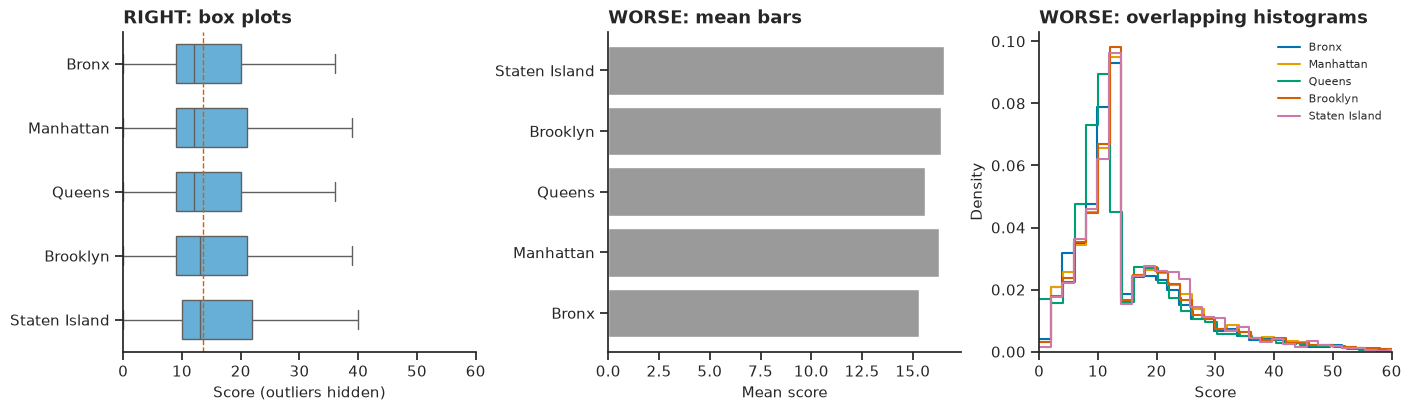

In [2]:
order = initial.groupby("boro")["score"].median().sort_values().index
fig, axs = plt.subplots(1, 3, figsize=(14, 4), layout="constrained")

sns.boxplot(data=initial, x="score", y="boro", order=order, ax=axs[0], color=PALETTE["sky"],
            showfliers=False, width=.6)
axs[0].axvline(13.5, color=PALETTE["red"], ls="--", lw=1)
axs[0].set(xlim=(0, 60), xlabel="Score (outliers hidden)", ylabel="", title="RIGHT: box plots")

means = initial.groupby("boro")["score"].mean().loc[order]
axs[1].barh(means.index, means.values, color=PALETTE["grey"])
axs[1].set(xlabel="Mean score", title="WORSE: mean bars")

for b in order:
    sns.histplot(initial[initial["boro"] == b]["score"], binwidth=2, element="step", fill=False,
                 stat="density", ax=axs[2], label=b)
axs[2].set(xlim=(0, 60), xlabel="Score", title="WORSE: overlapping histograms")
axs[2].legend(fontsize=8, frameon=False)

---
## Q2. "Has the share of surprise inspections scoring an A changed from 2015 to 2018?"

**Type:** a **trend** over time.

**Answer: a line chart of the monthly A share, with a confidence band (or at least the number of inspections per month noted), y-axis labelled in %.**
- *vs a bar per month:* 48 bars for a trend: the eye reads the bar *tops*, so it's a line drawn badly, with more ink and more clutter.
- *vs one pie chart per year:* pies compare parts of *one* whole, not change over time. Four pies make you compare angles across separate circles, which people do badly.

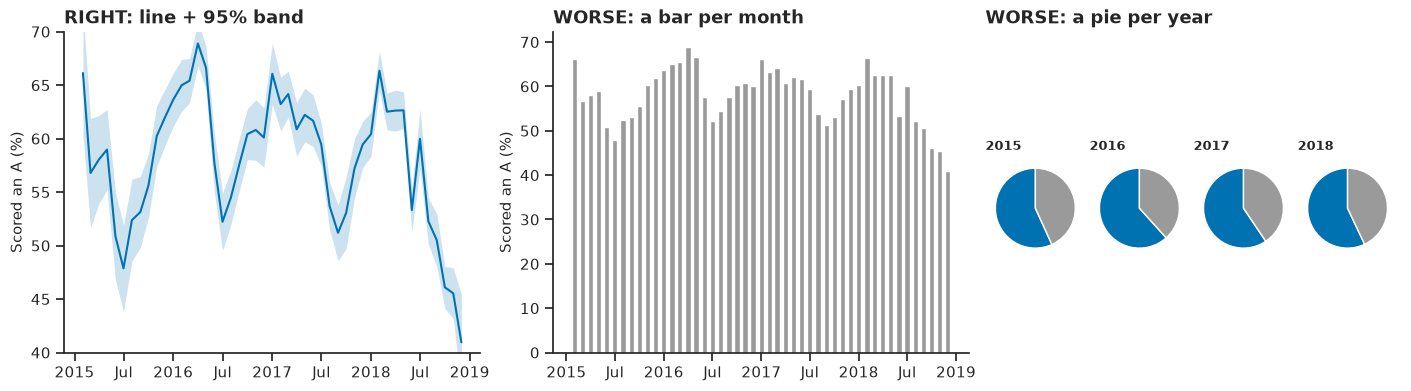

In [3]:
m = (initial.assign(month=lambda d: d["inspection_date"].dt.to_period("M").dt.to_timestamp(),
                    is_a=lambda d: d["score"] <= 13)
            .groupby("month")["is_a"].agg(["mean", "size"]))
m = m[m["size"] >= 200]                                   # drop thin months at the edges
se = np.sqrt(m["mean"] * (1 - m["mean"]) / m["size"])     # binomial standard error per month

fig, axs = plt.subplots(1, 3, figsize=(14, 3.8), layout="constrained")
axs[0].plot(m.index, m["mean"] * 100, color=PALETTE["blue"])
axs[0].fill_between(m.index, (m["mean"] - 1.96 * se) * 100, (m["mean"] + 1.96 * se) * 100,
                    color=PALETTE["blue"], alpha=.2, lw=0)
axs[0].set(ylabel="Scored an A (%)", ylim=(40, 70), title="RIGHT: line + 95% band")

axs[1].bar(m.index, m["mean"] * 100, width=20, color=PALETTE["grey"])
axs[1].set(ylabel="Scored an A (%)", title="WORSE: a bar per month")
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter
for ax in axs[:2]:
    loc = AutoDateLocator()
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(ConciseDateFormatter(loc))

yearly = initial.assign(year=initial["inspection_date"].dt.year, is_a=initial["score"] <= 13).groupby("year")["is_a"].mean()
axs[2].set_axis_off()
axs[2].set_title("WORSE: a pie per year")
for k, (yr, share) in enumerate(yearly.items()):
    ax_in = axs[2].inset_axes([k * 0.25, 0.1, 0.24, 0.7])
    ax_in.pie([share, 1 - share], colors=[PALETTE["blue"], PALETTE["grey"]], startangle=90)
    ax_in.set_title(str(yr), fontsize=9)

**What the line shows that the others hide:** a clear **seasonal cycle**: the A share is highest from January to May (about 63%) and lowest from August to October (about 53%), perhaps because summer heat makes temperature and pest violations more common (a hypothesis, not tested here) and a **drop at the end of 2018**. Treat that last drop with suspicion before believing it: the data dictionary says scores are updated after adjudication, so the most recent inspections, extracted in December 2018, may not be final yet. Without the line you'd never think to ask.

**Note on the y-axis:** a line chart doesn't need to start at zero (it shows change, and the eye reads slopes, not lengths), but say clearly that it doesn't. A **bar** chart must start at zero, because bar length *is* the value.

---
## Q3. "Does the surprise-inspection score predict whether the restaurant fails its next one?"

**Type:** a **relationship** between a numeric predictor and a yes/no outcome.

**Answer: bin the predictor, then plot the outcome rate per bin as points with 95% CIs, joined by a line** (P1 figure 4).
- *vs a scatter plot of 41,000 points:* the outcome is 0/1, so the points form two flat stripes with heavy overplotting. The relationship is invisible.
- *vs a single correlation coefficient:* one number hides the **shape** (steady climb, no jump at 13/14) and says nothing about the size of the risk in plain terms.

Text(0.0, 1.0, 'WORSE: one correlation')

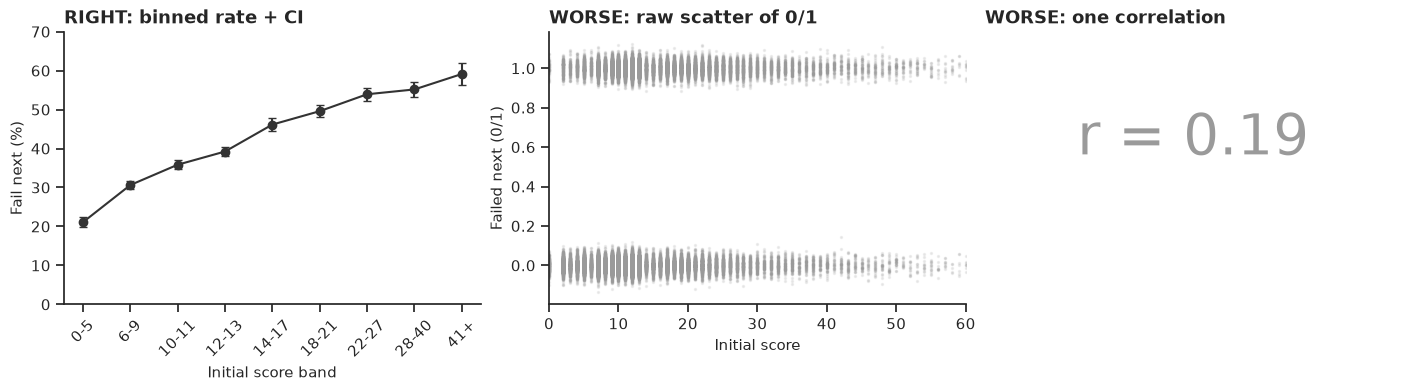

In [4]:
sys.path.insert(0, str(P1))
from src.analysis import cycle_inspections, build_grade_events
ev = build_grade_events(cycle_inspections(insp), rest.set_index("camis")["boro"]).dropna(subset=["next_score"])
bins = [-1, 5, 9, 11, 13, 17, 21, 27, 40, 200]
labels = ["0-5", "6-9", "10-11", "12-13", "14-17", "18-21", "22-27", "28-40", "41+"]
g = ev.assign(band=pd.cut(ev["initial_score"], bins, labels=labels)).groupby("band", observed=True)["next_fail"]
rate, n = g.mean(), g.size()
ci = 1.96 * np.sqrt(rate * (1 - rate) / n)   # simple binomial CI, enough for a sketch

fig, axs = plt.subplots(1, 3, figsize=(14, 3.8), layout="constrained")
axs[0].errorbar(range(len(labels)), rate * 100, yerr=ci * 100, fmt="o-", color=PALETTE["dark"], capsize=3)
axs[0].set_xticks(range(len(labels)), labels, rotation=45)
axs[0].set(ylim=(0, 70), xlabel="Initial score band", ylabel="Fail next (%)", title="RIGHT: binned rate + CI")

jit = np.random.default_rng(0).normal(0, .03, len(ev))
axs[1].scatter(ev["initial_score"], ev["next_fail"] + jit, s=2, alpha=.15, color=PALETTE["grey"])
axs[1].set(xlim=(0, 60), xlabel="Initial score", ylabel="Failed next (0/1)", title="WORSE: raw scatter of 0/1")

r = ev["initial_score"].corr(ev["next_fail"])
axs[2].set_axis_off()
axs[2].text(.5, .55, f"r = {r:.2f}", ha="center", fontsize=40, color=PALETTE["grey"])
axs[2].set_title("WORSE: one correlation")

---
## A template answer (say it in about 60 seconds)

> "The question is a **[distribution / comparison / relationship / composition / trend]** question, so I'd use **[chart]**, with **[the key encoding]**.
> I wouldn't use **[alternative 1]**, because **[what it hides or distorts]**, or **[alternative 2]**, because **[what it hides or distorts]**.
> I'd add **[uncertainty / reference line / annotation]** so the reader can see **[the point]**."

| Question type | First choice | Usual wrong choices |
| :-- | :-- | :-- |
| Distribution of one variable | histogram (+ density), ECDF | bar of the mean, pie |
| Distributions across groups | box / violin / ECDF per group, small multiples | mean bars, overlapping histograms |
| Comparison of a few numbers | dot plot or bars from zero, with CIs | 3-D bars, pies with many slices |
| Relationship, numeric-numeric | scatter (+ trend line), hexbin if many points | dual-axis line chart |
| Relationship, numeric → yes/no | binned rate with CIs, logistic curve | raw scatter of 0/1 |
| Composition | stacked bars (few parts), 100% bars | pie with > 4 slices, donuts |
| Trend over time | line (+ band), small multiples for groups | many bars, pies per period, dual axes |
| Correlations between many variables | heatmap, diverging palette centred at 0 | rainbow colormap (`jet`) |